
# Applied Text Analytics Coursework 2  
## Google Reviews Rating Prediction

This notebook includes:
- Data exploration and preprocessing
- TF-IDF feature engineering (unigram & bigram)
- Model training and evaluation
- Cross-validation and hyperparameter tuning
- Final model selection

The goal is to predict user ratings (1–5) from review text.


# Google-Review Prediction

**Course:** Applied Text Analysis
**Student Name:**
* Mohammad Safwan (H00531800)
* P.Harinath Reddy (H00530259)
* A.Chandrahas (H00530257)

**Date:** 10th April  


# Step 1: Data Exploration and Visualization

In this step we will load our test.csv and train.csv and then perform some analysis to understand the data and its ditribution


In [ ]:
import pandas as pd


In [ ]:
train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')

In [ ]:
train_data.head()

,text,rating
0,This place is TERRIBLE; the people in charge a...,2
1,Terrible Service! And they are saying that I n...,1
2,Absolutely terrible company. They sent me to ...,1
3,"To find it, either park in front of the Tuesda...",4
4,Mall location. Used their services for sedan. ...,4


In [ ]:
test_data.head()

,text,rating
0,Every time I’ve been hear they’ve done a great...,4
1,if u like calm and layed back without the ste...,4
2,I would give this place 0 if I could. My exper...,1
3,Had some problems viewing a place and was not ...,3
4,The staff at this place is very rude! They do ...,1


Now lets check the number of rows (samples) and columns (features) in both the training and testing datasets.


In [ ]:
print(f"train_data: {train_data.shape}")
print(f"test_data: {test_data.shape}")

#Output: The Training data consist of 288000 review and the test data contains 72000

train_data: (288000, 2)
test_data: (89100, 2)


In [ ]:
#lets check if the data consist of null columns
train_data.isnull().sum()

,0
text,0
rating,0


In [ ]:
# Checking how ratings are distributed in the training data
train_data['rating'].value_counts()

,count
rating,
1,109583
4,82073
3,35326
2,32218
5,28800


we can see that the ratings are imbalanced, with a higher number of 1-star reviews compared to other ratings. This imbalance may affect the performance of our predictive model

### Data Visualization


Text(0, 0.5, 'Count')

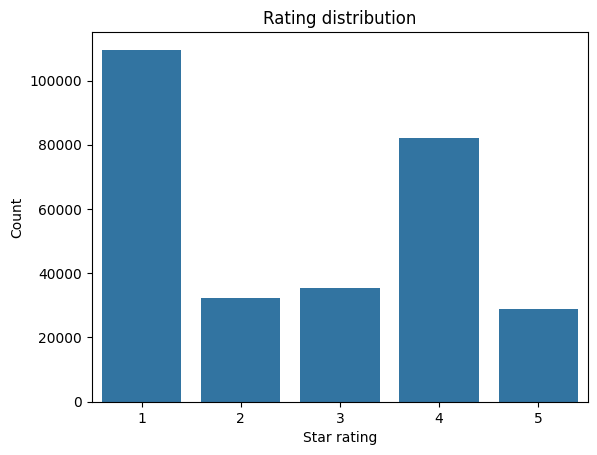

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='rating', data=train_data)
plt.title('Rating distribution')
plt.xlabel('Star rating')
plt.ylabel('Count')

<Axes: xlabel='rating', ylabel='word_count'>

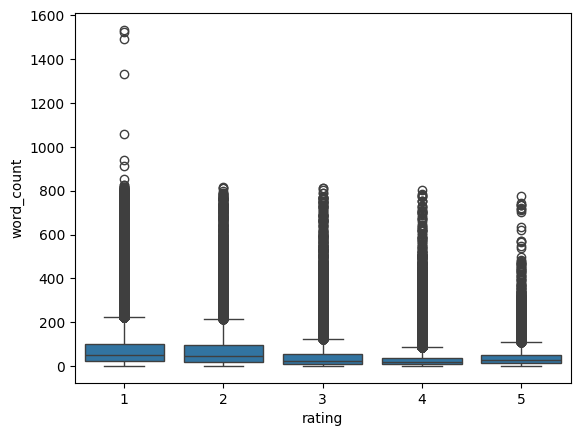

In [ ]:
train_data['word_count'] = train_data['text'].apply(lambda x: len(str(x).split()))
sns.boxplot(x='rating', y='word_count', data=train_data)

The boxplot above illustrates the distribution of word counts in the reviews for each star rating. We can observe that 1-star reviews tend to have a wider range of word counts, with some reviews being quite lengthy, while others are very short. In contrast, higher-rated reviews (4 and 5 stars) generally have a more consistent word count, often falling within a narrower range. This suggests that customers who leave negative feedback may provide more detailed explanations for their dissatisfaction, while those who are satisfied may be more concise in their reviews. Understanding this pattern can help us in feature engineering and model development for predicting review ratings based on text data.

To better understand the textual patterns in the dataset, we generate **word clouds** for:

- Negative reviews (1-star)
- Positive reviews (5-star)



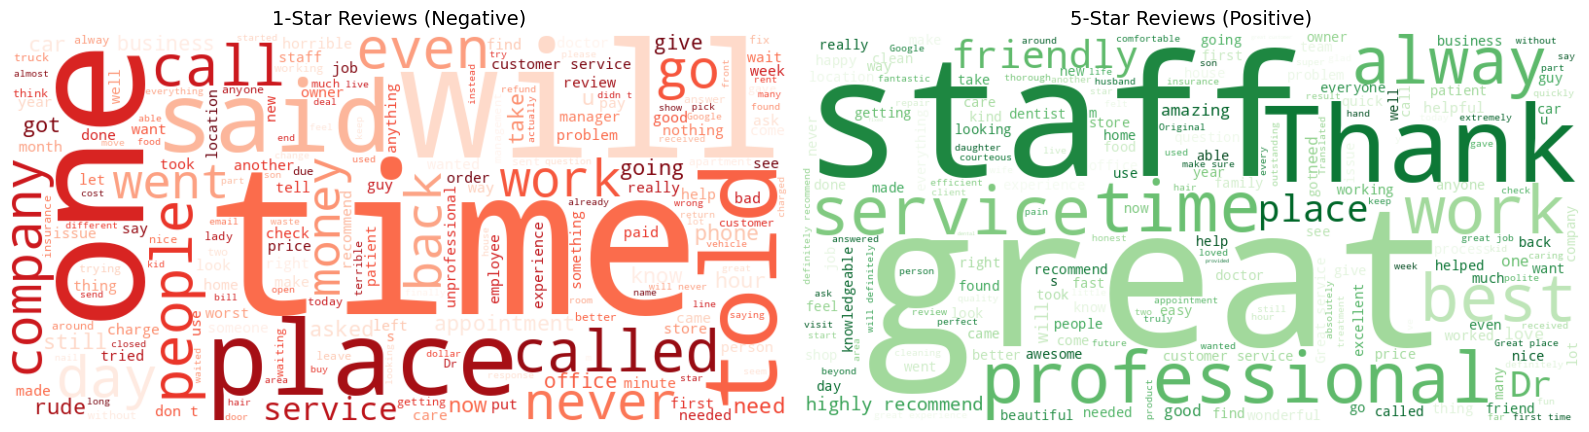

In [ ]:
# Word Cloud for 1-star vs 5-star
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, rating, title, color in zip(
    axes,
    [1, 5],
    ['1-Star Reviews (Negative)', '5-Star Reviews (Positive)'],
    ['Reds', 'Greens']
):
    text = ' '.join(train_data[train_data['rating'] == rating]['text'].dropna().astype(str).head(5000))
    wc = WordCloud(width=800, height=400, background_color='white', colormap=color).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontsize=14)
    ax.axis('off')

plt.tight_layout()
plt.show()

#Step 2 — Text Processing & Normalization


In this step, we preprocess the textual data to remove noise and improve the quality of input for the model.

The preprocessing techniques applied include:
- Removal of unnecessary characters and noise
- Removal of stopwords (common words like "the", "is", "and")
- Stemming (reducing words to their root form)
- Lemmatization (converting words to their meaningful base form)


In [ ]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words('english'))
stemmer    = PorterStemmer()
lemmatizer = WordNetLemmatizer()

Now lets define some funtion to perform preprcessing

In [ ]:
#Lowercase + remove punctuation/numbers
def clean_basic(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text.strip()

In [ ]:
#remove stopwords
def remove_stopwords(text):
    tokens = text.split()
    return ' '.join([w for w in tokens if w not in stop_words])

In [ ]:
#stemming
def stem_text(text):
    tokens = text.split()
    return ' '.join([stemmer.stem(w) for w in tokens])

In [ ]:
#lemmetization
def lemmatize_text(text):
    tokens = text.split()
    return ' '.join([lemmatizer.lemmatize(w) for w in tokens])

Now lets apply them and compare them


In [ ]:
sample = train_data['text'].iloc[0]
print("ORIGINAL:\n", sample[:300])
print("\nBASIC CLEAN:\n",      clean_basic(sample)[:300])
print("\nNO STOPWORDS:\n",     remove_stopwords(clean_basic(sample))[:300])
print("\nSTEMMED:\n",          stem_text(remove_stopwords(clean_basic(sample)))[:300])
print("\nLEMMATIZED:\n",       lemmatize_text(remove_stopwords(clean_basic(sample)))[:300])

ORIGINAL:
 This place is TERRIBLE; the people in charge are the worst part, by far.  Yeah, the place is beautiful inside but the people running it are not. The director can be nice at first but she can truly careless about you or your family.
Honestly, I only gave it two star because of some of the dedicated e

BASIC CLEAN:
 this place is terrible the people in charge are the worst part by far  yeah the place is beautiful inside but the people running it are not the director can be nice at first but she can truly careless about you or your family
honestly i only gave it two star because of some of the dedicated employee

NO STOPWORDS:
 place terrible people charge worst part far yeah place beautiful inside people running director nice first truly careless family honestly gave two star dedicated employees really enjoy dedication bring table reasons want bring children however suggestfor place become better experience reevaluate dir

STEMMED:
 place terribl peopl charg worst part far yea

##Stemming vs Lemmatization

From the preprocessing results, we can observe that **lemmatization performs better than stemming**.

###Reason

- **Stemming** reduces words to their root form by simply cutting off suffixes  
  - Example: *"running" → "run"*, *"better" → "bett"*  
  - It may produce **non-meaningful or incorrect words**

- **Lemmatization**, on the other hand, considers the **context and linguistic meaning** of words  
  - Example: *"running" → "run"*, *"better" → "good"*  
  - It produces **valid and meaningful base words**

Although lemmatization is computationally more expensive than stemming, it generally leads to **better performance in NLP tasks**.


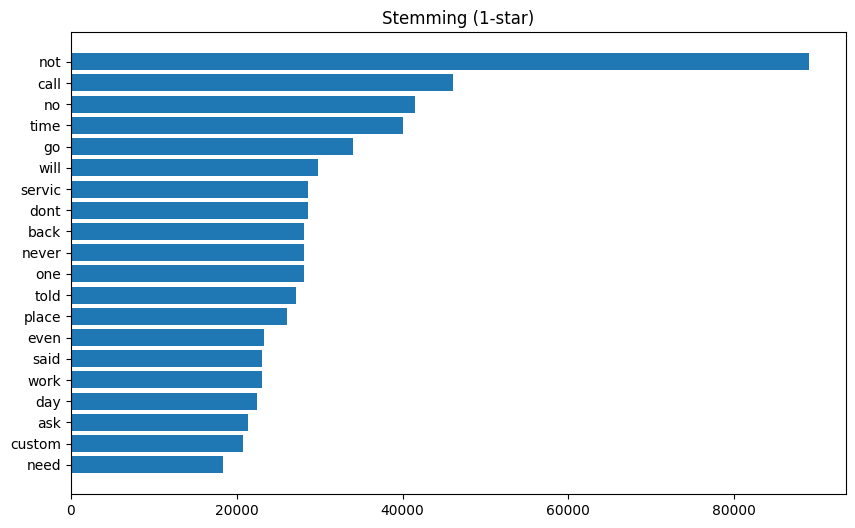

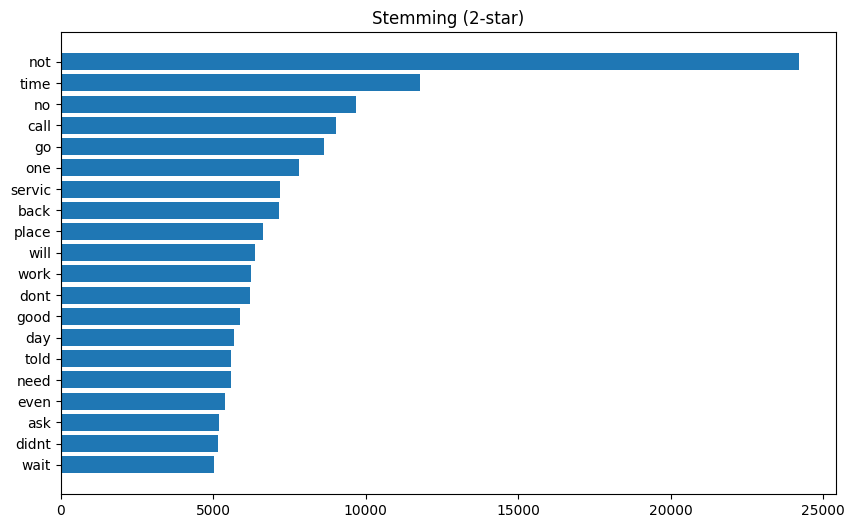

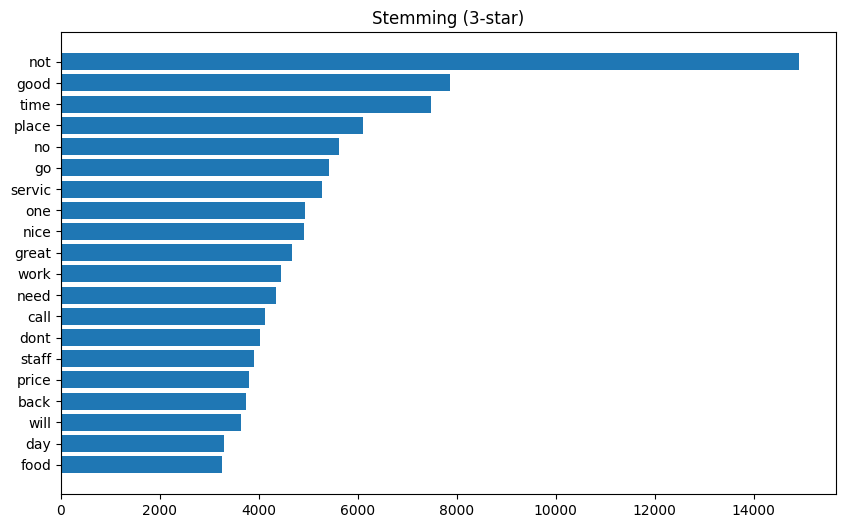

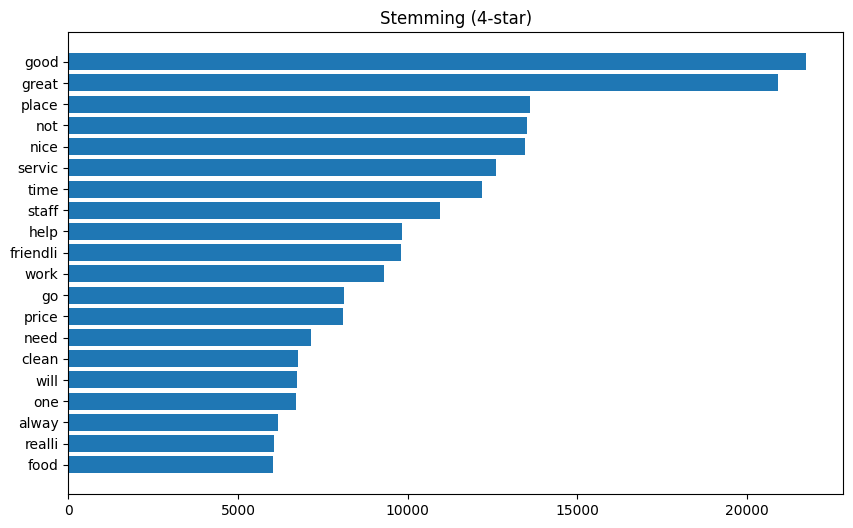

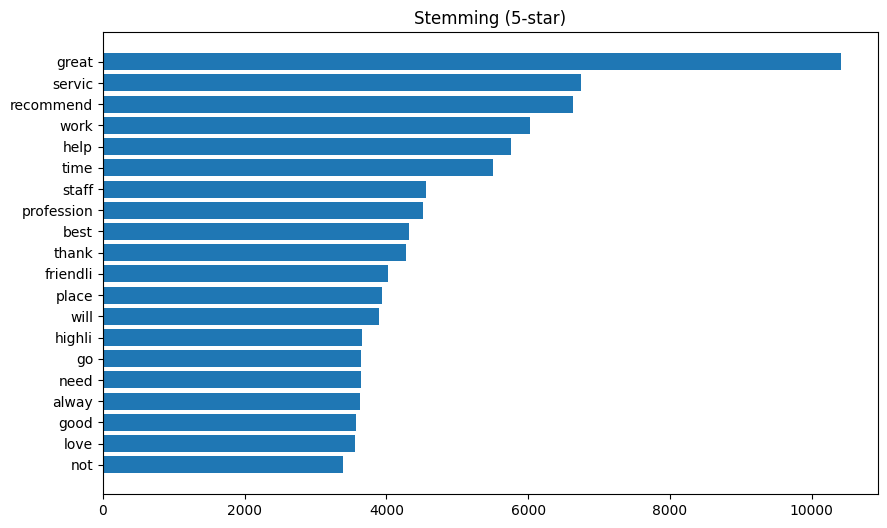

In [ ]:
import re
from collections import Counter
from wordcloud import STOPWORDS


stemmer = PorterStemmer()
stop_words = set(STOPWORDS) - {"not", "no", "nor"}

# Loop through ratings
for rating in [1, 2, 3, 4, 5]:

    # Get text data for the rating
    texts = train_data[train_data['rating'] == rating]['text'].dropna()

    text = ' '.join(texts)

    # Apply preprocessing pipeline
    text = clean_basic(text)
    text = remove_stopwords(text)
    text = stem_text(text)

    # Get word frequency
    words = text.split()
    top20 = Counter(words).most_common(20)

    # Convert to DataFrame
    df = pd.DataFrame(top20, columns=['word', 'count'])

    # Plot
    plt.figure(figsize=(10, 6))
    plt.barh(df['word'], df['count'])
    plt.gca().invert_yaxis()
    plt.title(f'Stemming ({rating}-star)')
    plt.xlabel("Frequency")
    plt.ylabel("Words")
    plt.show()

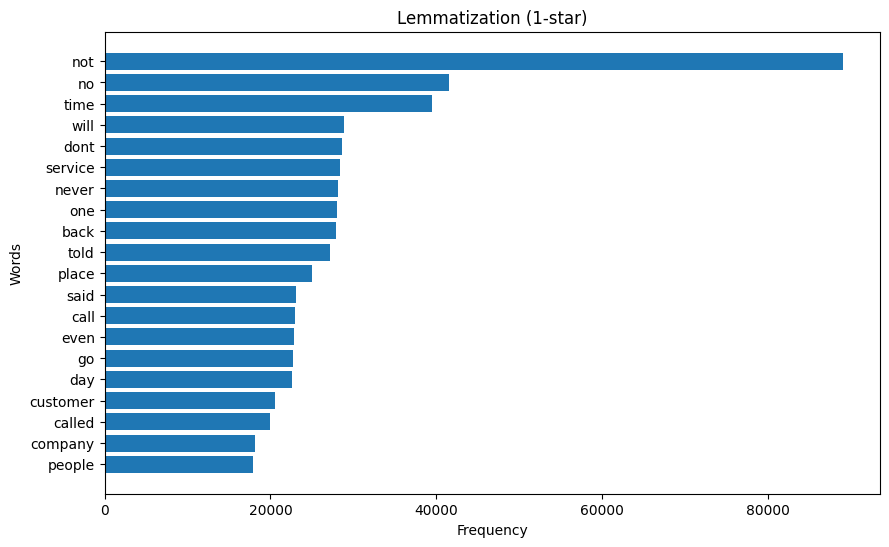

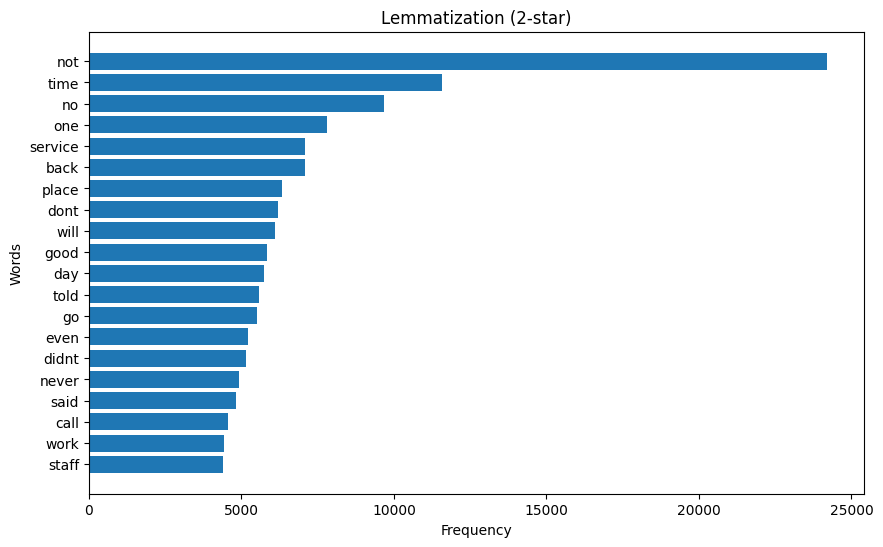

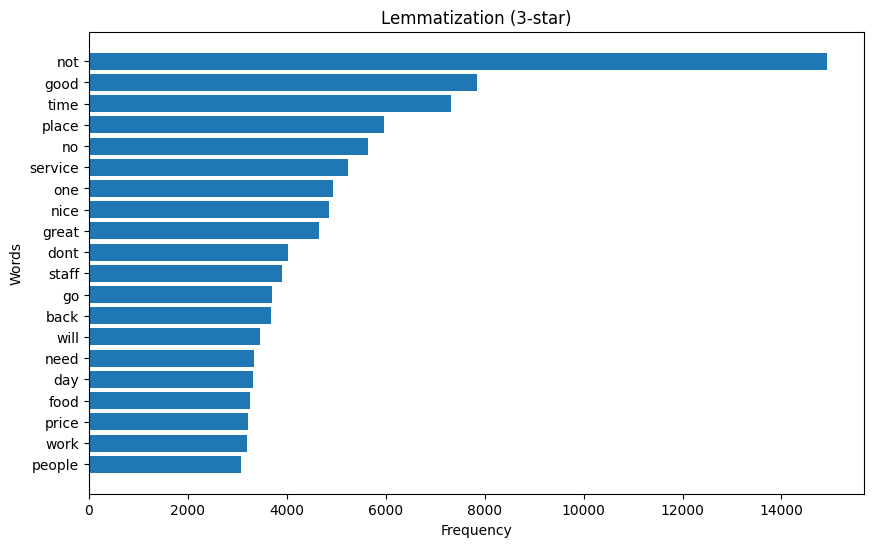

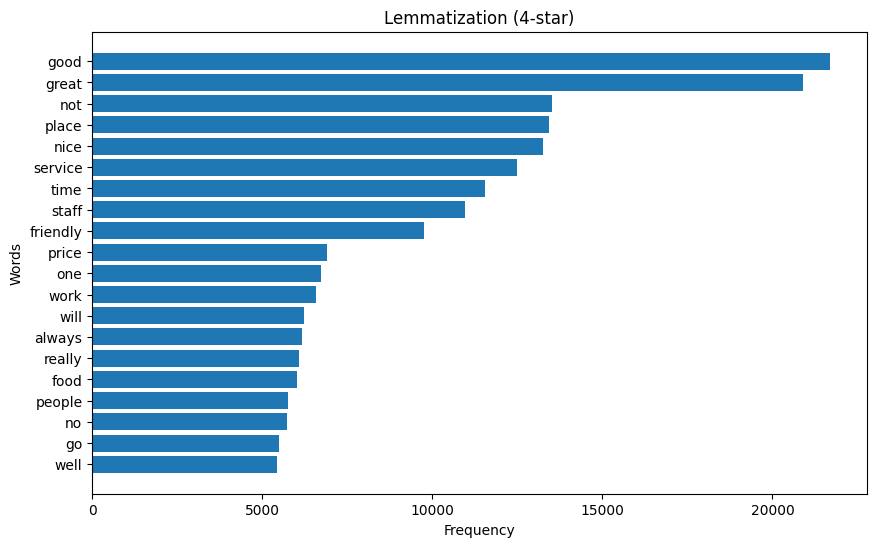

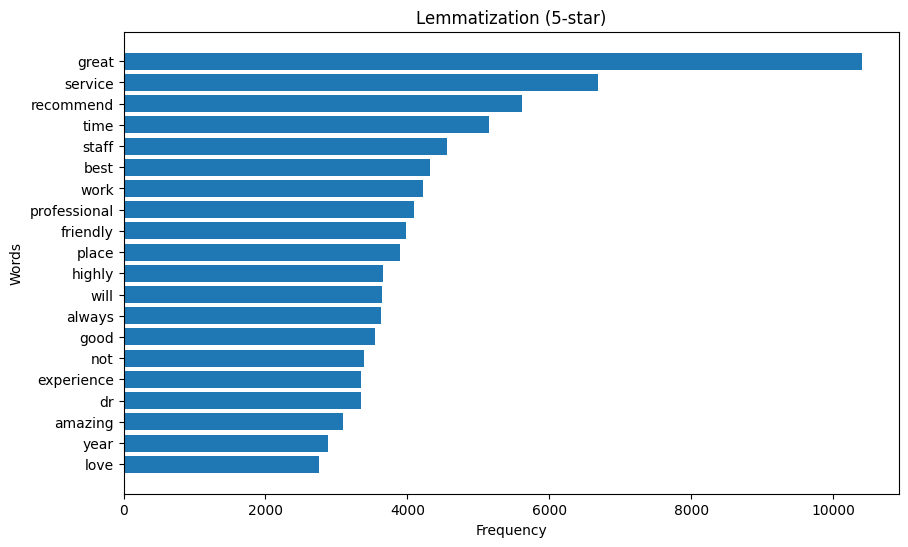

In [ ]:
# Initialize tools
lemmatizer = WordNetLemmatizer()
stop_words = set(STOPWORDS) - {"not", "no", "nor"}

# Loop through ratings
for rating in [1, 2, 3, 4, 5]:

    # Get text data for the rating
    texts = train_data[train_data['rating'] == rating]['text'].dropna()

    # Combine all reviews
    text = ' '.join(texts)

    # Apply preprocessing pipeline
    text = clean_basic(text)
    text = remove_stopwords(text)
    text = lemmatize_text(text)

    # Get word frequency
    words = text.split()
    top20 = Counter(words).most_common(20)

    # Convert to DataFrame
    df = pd.DataFrame(top20, columns=['word', 'count'])

    # Plot
    plt.figure(figsize=(10, 6))
    plt.barh(df['word'], df['count'])
    plt.gca().invert_yaxis()
    plt.title(f'Lemmatization ({rating}-star)')
    plt.xlabel("Frequency")
    plt.ylabel("Words")
    plt.show()

In [ ]:
#so now we perform all the steps to the dataset
def full_pipeline(text):
    text = clean_basic(text)
    text = remove_stopwords(text)
    text = lemmatize_text(text)
    return text

In [ ]:
train_sample = train_data.sample(n=50000, random_state=42).copy()
train_sample['processed'] = train_sample['text'].apply(full_pipeline)

In [ ]:
train_sample[['text','processed']].head(3)

,text,processed
124821,"Cheap haircut, friendly service",cheap haircut friendly service
40368,Dont Call she is one rude woman store has no time,dont call one rude woman store no time
118349,"There's a discount for disabled passengers, bu...",there discount disabled passenger point sign s...


In [ ]:
compare_df = train_data.head(2000).copy()
compare_df['original_tokens']    = compare_df['text'].apply(lambda x: len(str(x).split()))
compare_df['after_clean']        = compare_df['text'].apply(clean_basic)
compare_df['after_stopwords']    = compare_df['after_clean'].apply(remove_stopwords)
compare_df['after_lemmatize']    = compare_df['after_stopwords'].apply(lemmatize_text)
compare_df['clean_tokens']       = compare_df['after_clean'].apply(lambda x: len(x.split()))
compare_df['nostop_tokens']      = compare_df['after_stopwords'].apply(lambda x: len(x.split()))
compare_df['lemma_tokens']       = compare_df['after_lemmatize'].apply(lambda x: len(x.split()))

print("Average token counts at each pipeline stage:")
print(compare_df[['original_tokens','clean_tokens','nostop_tokens','lemma_tokens']].mean().round(1))


Average token counts at each pipeline stage:
original_tokens    57.3
clean_tokens       56.4
nostop_tokens      28.3
lemma_tokens       28.3
dtype: float64


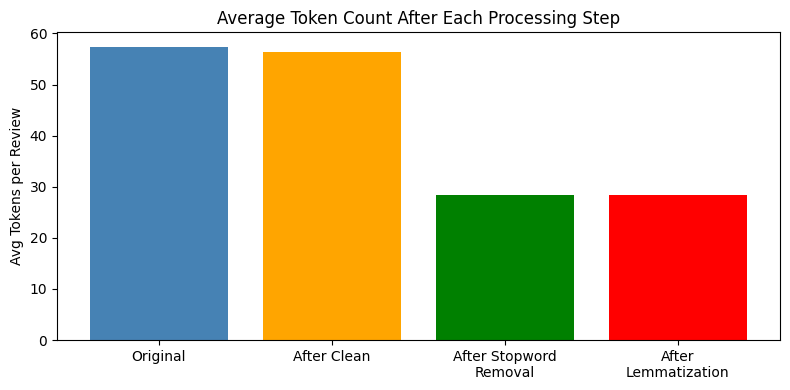

In [ ]:
stages = ['Original', 'After Clean', 'After Stopword\nRemoval', 'After\nLemmatization']
avg_tokens = compare_df[['original_tokens','clean_tokens','nostop_tokens','lemma_tokens']].mean()

plt.figure(figsize=(8,4))
plt.bar(stages, avg_tokens, color=['steelblue','orange','green','red'])
plt.title('Average Token Count After Each Processing Step')
plt.ylabel('Avg Tokens per Review')
plt.tight_layout()
plt.show()

#Step 3 — Vector Space Model & Feature Representation


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
import numpy as np

# Use processed text from train_sample
X = train_sample['processed']
y = train_sample['rating']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train)} | Val: {len(X_val)}")

Train: 40000 | Val: 10000


In [ ]:
vectorizers = {
    'Binary':    CountVectorizer(max_features=20000, binary=True),
    'Count':     CountVectorizer(max_features=20000),
    'TF-IDF':    TfidfVectorizer(max_features=20000),
}

In [ ]:
results = []
for name, vec in vectorizers.items():
    X_tr = vec.fit_transform(X_train)
    X_vl = vec.transform(X_val)
    clf  = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(X_tr, y_train)
    acc  = accuracy_score(y_val, clf.predict(X_vl))
    results.append({'Vectorizer': name, 'Accuracy': round(acc, 4)})
    print(f"{name}: {acc:.4f}")

import pandas as pd
print(pd.DataFrame(results))

Binary: 0.6019
Count: 0.6001
TF-IDF: 0.6388
  Vectorizer  Accuracy
0     Binary    0.6019
1      Count    0.6001
2     TF-IDF    0.6388


In [ ]:
ngram_configs = {
    'Unigram (1,1)':      (1,1),
    'Bigram (1,2)':       (1,2),
    'Trigram (1,3)':      (1,3),
    'Only Bigram (2,2)':  (2,2),
}

In [ ]:
ngram_results = []
for name, ngram in ngram_configs.items():
    vec  = TfidfVectorizer(max_features=30000, ngram_range=ngram)
    X_tr = vec.fit_transform(X_train)
    X_vl = vec.transform(X_val)
    clf  = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(X_tr, y_train)
    acc  = accuracy_score(y_val, clf.predict(X_vl))
    ngram_results.append({'N-gram': name, 'Accuracy': round(acc, 4)})
    print(f"{name}: {acc:.4f}")

ngram_df = pd.DataFrame(ngram_results)
print(ngram_df)

Unigram (1,1): 0.6376
Bigram (1,2): 0.6375
Trigram (1,3): 0.6386
Only Bigram (2,2): 0.5865
              N-gram  Accuracy
0      Unigram (1,1)    0.6376
1       Bigram (1,2)    0.6375
2      Trigram (1,3)    0.6386
3  Only Bigram (2,2)    0.5865


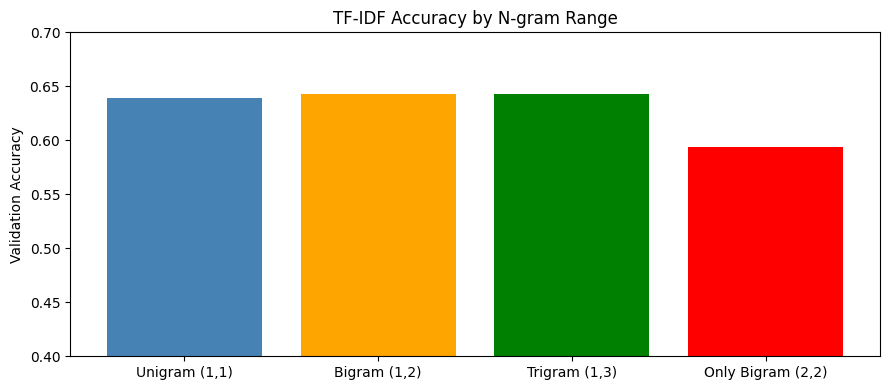

In [ ]:
plt.figure(figsize=(9,4))
plt.bar(ngram_df['N-gram'], ngram_df['Accuracy'], color=['steelblue','orange','green','red'])
plt.title('TF-IDF Accuracy by N-gram Range')
plt.ylabel('Validation Accuracy')
plt.ylim(0.4, 0.7)
plt.tight_layout()
plt.show()

From above graph we can observe that Bigram gave better accuracy so we will be using bigram

In [ ]:
# Testing how different vocabulary sizes affect model accuracy using TF-IDF and Logistic Regression.
vocab_results = []
for max_f in [1000, 5000, 10000, 20000, 50000]:
    vec  = TfidfVectorizer(max_features=max_f, ngram_range=(1,2))
    X_tr = vec.fit_transform(X_train)
    X_vl = vec.transform(X_val)
    clf  = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(X_tr, y_train)
    acc  = accuracy_score(y_val, clf.predict(X_vl))
    vocab_results.append({'max_features': max_f, 'Accuracy': round(acc,4)})
    print(f"Vocab {max_f}: {acc:.4f}")
vocab_df = pd.DataFrame(vocab_results)

Vocab 1000: 0.6288
Vocab 5000: 0.6354
Vocab 10000: 0.6381
Vocab 20000: 0.6360
Vocab 50000: 0.6385


Plotting how accuracy changes with different vocabulary sizes to visually compare performance.

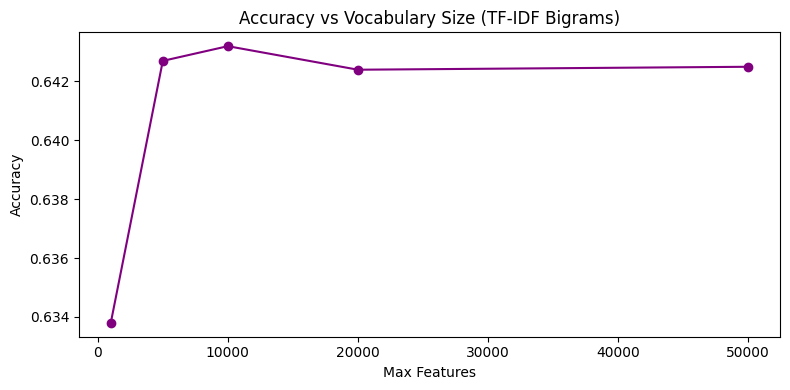

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(vocab_df['max_features'], vocab_df['Accuracy'], marker='o', color='purple')
plt.title('Accuracy vs Vocabulary Size (TF-IDF Bigrams)')
plt.xlabel('Max Features')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()

Training the model using the best vocabulary size and evaluating its performance on validation data.

In [ ]:
best_vec = TfidfVectorizer(max_features=30000, ngram_range=(1,2))
X_tr = best_vec.fit_transform(X_train)
X_vl = best_vec.transform(X_val)
clf  = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_tr, y_train)
y_pred = clf.predict(X_vl)

print("Best Model — TF-IDF Bigrams + Logistic Regression")
print(classification_report(y_val, y_pred))

Best Model — TF-IDF Bigrams + Logistic Regression
              precision    recall  f1-score   support

           1       0.71      0.92      0.80      3807
           2       0.35      0.10      0.15      1123
           3       0.39      0.15      0.22      1223
           4       0.60      0.77      0.67      2842
           5       0.61      0.41      0.49      1005

    accuracy                           0.64     10000
   macro avg       0.53      0.47      0.47     10000
weighted avg       0.59      0.64      0.59     10000



#Step 4 — Model Training, Selection & Hyperparameter Tuning

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
# Preparing TF-IDF features
vec = TfidfVectorizer(max_features=30000, ngram_range=(1,2))
X_vec = vec.fit_transform(train_sample['processed'])
y_all = train_sample['rating']

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Multinomial NB':      MultinomialNB(alpha=1.0),
    'Linear SVM':          LinearSVC(max_iter=2000, random_state=42),
}

In [ ]:
cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_vec, y_all, cv=cv,
                             scoring='accuracy', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name}: {scores.mean():.4f} ± {scores.std():.4f}")

Logistic Regression: 0.6433 ± 0.0016
Multinomial NB: 0.6062 ± 0.0021
Linear SVM: 0.6124 ± 0.0020


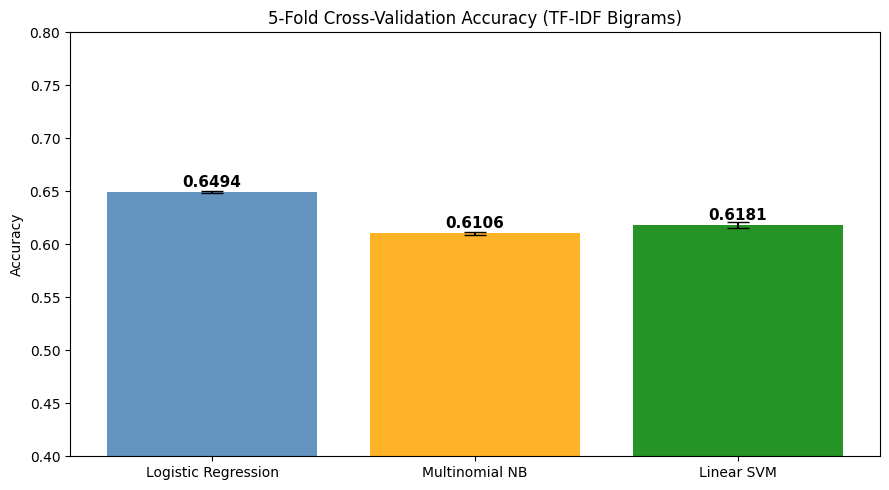

In [ ]:
# Running cross-validation for different models and comparing their accuracy scores.
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(9,5))
names  = list(cv_results.keys())
means  = [cv_results[n].mean() for n in names]
stds   = [cv_results[n].std()  for n in names]

bars = ax.bar(names, means, yerr=stds, capsize=8,
              color=['steelblue','orange','green'], alpha=0.85)
ax.set_title('5-Fold Cross-Validation Accuracy (TF-IDF Bigrams)')
ax.set_ylabel('Accuracy')
ax.set_ylim(0.4, 0.8)
for bar, m in zip(bars, means):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{m:.4f}', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Using GridSearchCV to find the best regularization parameter (C) for Logistic Regression.
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=30000, ngram_range=(1,2))),
    ('clf',   LogisticRegression(max_iter=1000, random_state=42))
])

param_grid = {'clf__C': [0.01, 0.1, 1, 10]}

grid = GridSearchCV(pipe, param_grid, cv=3, scoring='accuracy',
                    n_jobs=-1, verbose=1)
grid.fit(train_sample['processed'], train_sample['rating'])

print("Best C:", grid.best_params_)
print("Best CV Accuracy:", round(grid.best_score_, 4))

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best C: {'clf__C': 1}
Best CV Accuracy: 0.6391


In [ ]:
#Splitting data into training and validation sets, then using the best tuned model to make predictions
from sklearn.model_selection import train_test_split

X_tr, X_vl, y_tr, y_vl = train_test_split(
    train_sample['processed'], train_sample['rating'],
    test_size=0.2, random_state=42, stratify=train_sample['rating']
)

best_model = grid.best_estimator_
y_pred = best_model.predict(X_vl)

print(classification_report(y_vl, y_pred))

              precision    recall  f1-score   support

           1       0.77      0.96      0.86      3807
           2       0.81      0.27      0.41      1123
           3       0.78      0.37      0.50      1223
           4       0.70      0.89      0.78      2842
           5       0.81      0.58      0.68      1005

    accuracy                           0.75     10000
   macro avg       0.78      0.61      0.65     10000
weighted avg       0.76      0.75      0.72     10000



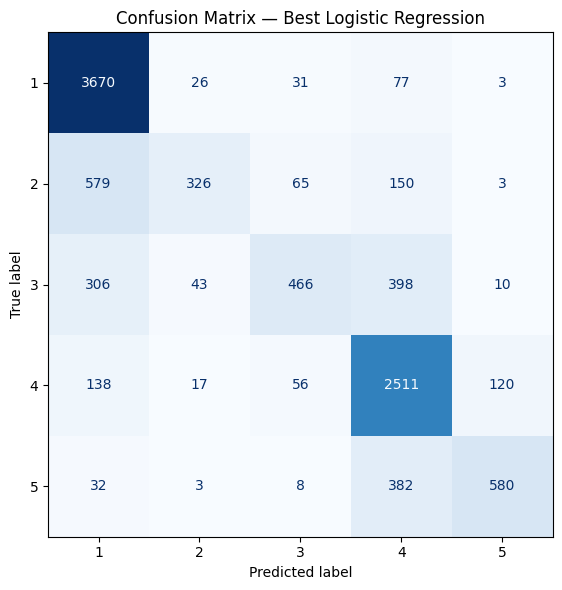

In [ ]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(7,6))
ConfusionMatrixDisplay.from_predictions(y_vl, y_pred, ax=ax,
    colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Best Logistic Regression')
plt.tight_layout()
plt.show()

In [ ]:
print(test_data.head())

   index  Id                                               text  \
0      0   1  Quite easy to rent a car bur it is not easy to...   
1      1   2  Nice voleyball court close to restaurants and ...   
2      2   3  Very nice built homes, the future locations ar...   
3      3   4  This dental clinic appears to be friendly with...   
4      4   5  We came in to discuss tattoos.  Only person th...   

                                           processed  
0    quite easy rent car bur easy find parking place  
1   nice voleyball court close restaurant everything  
2           nice built home future location pleasing  
3  dental clinic appears friendly receptionist ca...  
4  came discus tattoo person time rebecca left fe...  


In [ ]:

# Reset index to preserve original IDs
test_data = test_data.reset_index(drop=False)  # keeps old index as a column

# Fill NaNs in raw text
test_data['text'] = test_data['text'].fillna('')

# Apply pipeline and fill any NaNs in processed output too
test_data['processed'] = test_data['text'].apply(full_pipeline)
test_data['processed'] = test_data['processed'].fillna('')

print(f"Test data size: {len(test_data)}")  # should be 89100


Test data size: 89100


In [ ]:
# Generating predictions on test data using the best model and saving results in submission format.
y_pred = grid.best_estimator_.predict(test_data['processed'])

submission = pd.DataFrame({
    'Id': test_data['Id'],
    'Rating': y_pred
})


print(f"Submission size: {len(submission)}")
submission.to_csv('Submission.csv', index=False)
print(submission.head())

Submission size: 89100
   Id  Rating
0   1       4
1   2       4
2   3       4
3   4       4
4   5       1


In [ ]:
test_data.shape

(72000, 3)

In [ ]:
submission = pd.DataFrame({
    'Id': test_data_3.index,
    'Rating': y_pred
})

submission.to_csv('predictions.csv', index=False)
print(submission.head())

   Id  Rating
0   0       4
1   1       4
2   2       4
3   3       4
4   4       1


#Step 5 — LSTM Sequence Model

In [ ]:
train_data['processed'] = train_data['text'].apply(full_pipeline)
test_data['processed'] = test_data['text'].apply(full_pipeline)

In [ ]:
X_train = train_data['processed']
y_train = train_data['rating']
X_test = test_data['processed']

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_VOCAB = 30000
MAX_LEN = 200

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=MAX_LEN)
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=MAX_LEN)

# convert labels to 0-indexed
y_train_enc = y_train - 1

In [ ]:
# Building and compiling a bidirectional LSTM model for sequence-based text classification.
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional

model = Sequential([
    Embedding(MAX_VOCAB, 128, input_length=MAX_LEN),
    Bidirectional(LSTM(128, return_sequences=False)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(5, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Training the LSTM model with early stopping to prevent overfitting and improve performance.
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
history = model.fit(X_train_seq, y_train_enc, validation_split=0.1, epochs=10, batch_size=128,callbacks=[early_stop])

Epoch 1/10
2025/2025 ━━━━━━━━━━━━━━━━━━━━ 84s 37ms/step - accuracy: 0.6395 - loss: 0.9155 - val_accuracy: 0.6577 - val_loss: 0.8499
Epoch 2/10
2025/2025 ━━━━━━━━━━━━━━━━━━━━ 93s 44ms/step - accuracy: 0.6788 - loss: 0.8056 - val_accuracy: 0.6636 - val_loss: 0.8343
Epoch 3/10
2025/2025 ━━━━━━━━━━━━━━━━━━━━ 78s 39ms/step - accuracy: 0.7031 - loss: 0.7471 - val_accuracy: 0.6614 - val_loss: 0.8513
Epoch 4/10
2025/2025 ━━━━━━━━━━━━━━━━━━━━ 75s 37ms/step - accuracy: 0.7267 - loss: 0.6915 - val_accuracy: 0.6581 - val_loss: 0.8797


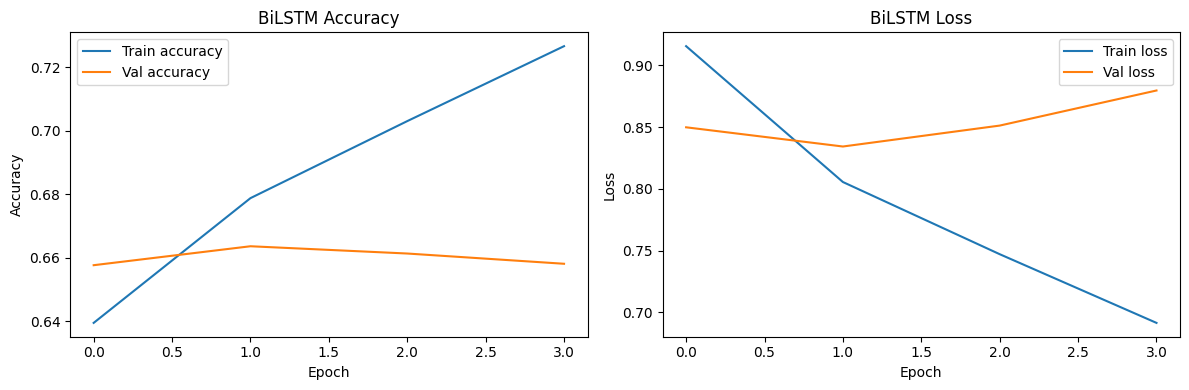

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train accuracy')
plt.plot(history.history['val_accuracy'], label='Val accuracy')
plt.title('BiLSTM Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.title('BiLSTM Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('bilstm_training_history.png')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X_tr_seq, X_val_seq, y_tr_enc, y_val_enc = train_test_split(
    X_train_seq, y_train_enc, test_size=0.1, random_state=42, stratify=y_train_enc
)

# Refit on 90% only (to match what model saw)
y_pred_probs = model.predict(X_val_seq)
y_pred = np.argmax(y_pred_probs, axis=1)

# Classification report (add 1 back to match original labels 1-5)
print(classification_report(y_val_enc + 1, y_pred + 1, target_names=['1-star','2-star','3-star','4-star','5-star']))

900/900 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step
              precision    recall  f1-score   support

      1-star       0.78      0.94      0.85     10958
      2-star       0.46      0.19      0.27      3222
      3-star       0.48      0.28      0.35      3533
      4-star       0.69      0.81      0.75      8207
      5-star       0.69      0.66      0.67      2880

    accuracy                           0.71     28800
   macro avg       0.62      0.57      0.58     28800
weighted avg       0.67      0.71      0.68     28800



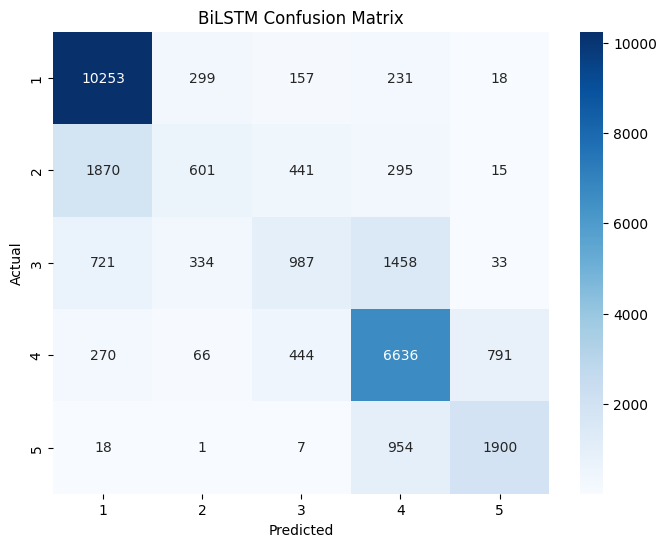

In [ ]:
cm = confusion_matrix(y_val_enc, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['1','2','3','4','5'],
            yticklabels=['1','2','3','4','5'],
            cmap='Blues')
plt.title('BiLSTM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('bilstm_confusion_matrix.png')
plt.show()

In [ ]:
y_test_probs = model.predict(X_test_seq)
y_test_pred = np.argmax(y_test_probs, axis=1) + 1  # convert back to 1-5


submission_lstm = pd.DataFrame({
    'id': range(len(y_test_pred)),
    'rating': y_test_pred
})

submission_lstm.to_csv('submission_bilstm.csv', index=False)
print('BiLSTM submission saved')
print(submission_lstm['rating'].value_counts().sort_index())

2250/2250 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step
BiLSTM submission saved
rating
1    33006
2     3157
3     5016
4    23846
5     6975
Name: count, dtype: int64


#BERT

In [ ]:
import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split

In [ ]:
train_sample = train_data.sample(n=50000, random_state=42).reset_index(drop=True)

In [ ]:
# Adjusting labels to start from 0 and splitting data into training and validation sets.
train_sample['label'] = train_sample['rating'] - 1

X_tr, X_val, y_tr, y_val = train_test_split(
    train_sample['text'].tolist(),
    train_sample['label'].tolist(),
    test_size=0.1,
    random_state=42,
    stratify=train_sample['label']
)

In [ ]:
print(f'Train: {len(X_tr)}, Val: {len(X_val)}')

Train: 45000, Val: 5000


In [ ]:
# Loading a pre-trained BERT tokenizer and testing it on a sample sentence.
MODEL_NAME = 'nlptown/bert-base-multilingual-uncased-sentiment'
tokenizer_bert = AutoTokenizer.from_pretrained(MODEL_NAME)
sample = tokenizer_bert("Great food and service!", truncation=True, max_length=128)
print(sample)

config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

{'input_ids': [101, 11838, 15225, 10110, 11416, 106, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1]}


In [ ]:
# Create PyTorch Dataset
class ReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            max_length=self.max_len,
            padding='max_length',
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Create datasets
train_dataset = ReviewDataset(X_tr, y_tr, tokenizer_bert)
val_dataset = ReviewDataset(X_val, y_val, tokenizer_bert)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

print(f'Train batches: {len(train_loader)}, Val batches: {len(val_loader)}')

Train batches: 1407, Val batches: 79


In [ ]:
print('GPU available:', torch.cuda.is_available())
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

GPU available: True
Using device: cuda


In [ ]:
model_bert = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=5,
    ignore_mismatched_sizes=True  # needed since original model has different head
)
model_bert = model_bert.to(device)

# Optimizer and scheduler
EPOCHS = 3
optimizer = AdamW(model_bert.parameters(), lr=2e-5, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
# Training loop
from tqdm import tqdm

best_val_f1 = 0
train_losses = []
val_f1s = []

for epoch in range(EPOCHS):
    # --- Training ---
    model_bert.train()
    total_loss = 0

    for batch in tqdm(train_loader, desc=f'Epoch {epoch+1} training'):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model_bert(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model_bert.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # --- Validation ---
    model_bert.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f'Epoch {epoch+1} validation'):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model_bert(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_f1 = f1_score(all_labels, all_preds, average='weighted')
    val_f1s.append(val_f1)

    print(f'Epoch {epoch+1}: Train loss = {avg_train_loss:.4f}, Val F1 = {val_f1:.4f}')

    # Save best model
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model_bert.state_dict(), 'best_bert_model.pt')
        print(f'  New best model saved (F1={val_f1:.4f})')

print(f'\nBest Val F1: {best_val_f1:.4f}')

Epoch 1 validation: 100%|██████████| 79/79 [00:42<00:00,  1.87it/s]


Epoch 1: Train loss = 0.8180, Val F1 = 0.6525
  New best model saved (F1=0.6525)


Epoch 2 validation: 100%|██████████| 79/79 [00:42<00:00,  1.87it/s]


Epoch 2: Train loss = 0.7087, Val F1 = 0.6652
  New best model saved (F1=0.6652)


Epoch 3 validation: 100%|██████████| 79/79 [00:42<00:00,  1.87it/s]


Epoch 3: Train loss = 0.6047, Val F1 = 0.6675
  New best model saved (F1=0.6675)

Best Val F1: 0.6675


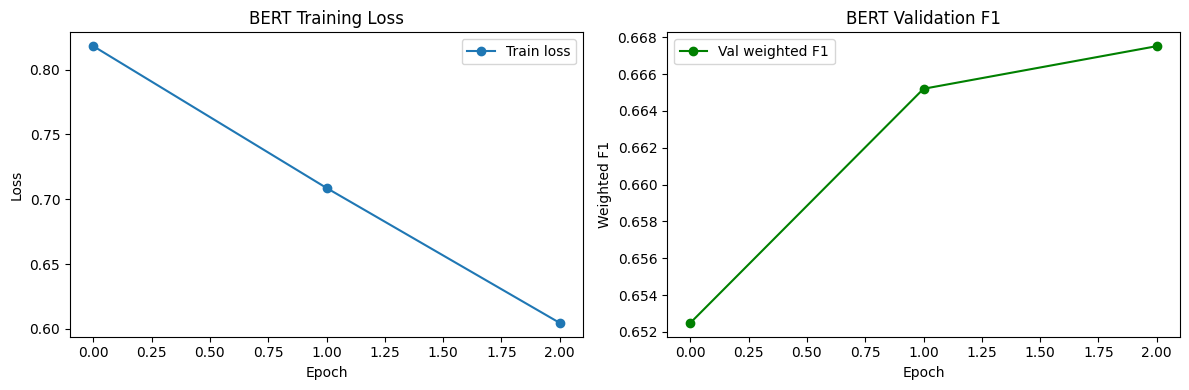

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, marker='o', label='Train loss')
plt.title('BERT Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(val_f1s, marker='o', color='green', label='Val weighted F1')
plt.title('BERT Validation F1')
plt.xlabel('Epoch')
plt.ylabel('Weighted F1')
plt.legend()

plt.tight_layout()
plt.savefig('bert_training_history.png')
plt.show()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

model_bert.load_state_dict(torch.load('best_bert_model.pt'))
model_bert.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in val_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        outputs = model_bert(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Classification report
print(classification_report(
    [l+1 for l in all_labels],
    [p+1 for p in all_preds],
    target_names=['1-star','2-star','3-star','4-star','5-star']
))

              precision    recall  f1-score   support

      1-star       0.81      0.88      0.84      1904
      2-star       0.38      0.28      0.32       561
      3-star       0.40      0.35      0.37       611
      4-star       0.70      0.74      0.72      1421
      5-star       0.63      0.60      0.61       503

    accuracy                           0.68      5000
   macro avg       0.58      0.57      0.57      5000
weighted avg       0.66      0.68      0.67      5000



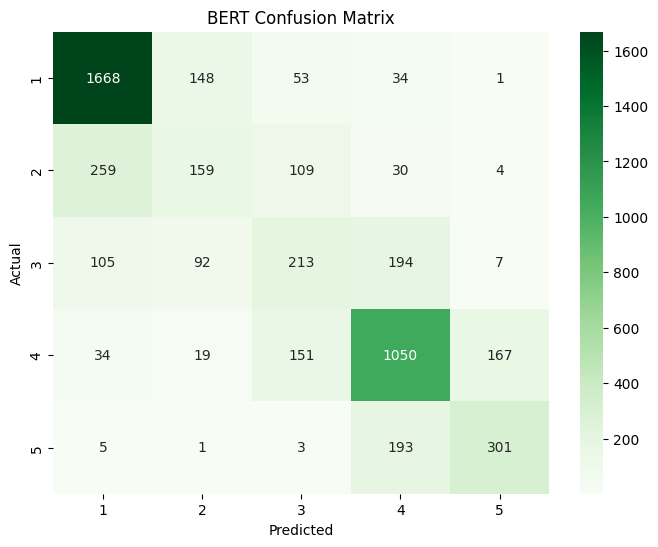

In [ ]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['1','2','3','4','5'],
            yticklabels=['1','2','3','4','5'],
            cmap='Greens')
plt.title('BERT Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('bert_confusion_matrix.png')
plt.show()

In [ ]:
# Create test dataset (no labels)
class TestDataset(Dataset):
    def __init__(self, texts, tokenizer, max_len=128):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            max_length=self.max_len,
            padding='max_length',
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze()
        }

test_dataset = TestDataset(test_data['text'].tolist(), tokenizer_bert)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Predict
model_bert.eval()
bert_test_preds = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc='Predicting test set'):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)

        outputs = model_bert(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)
        bert_test_preds.extend(preds.cpu().numpy())

# Convert back to 1-5
bert_test_preds_labels = [p + 1 for p in bert_test_preds]

# Save submission
submission_bert = pd.DataFrame({
    'id': range(len(bert_test_preds_labels)),
    'rating': bert_test_preds_labels
})
submission_bert.to_csv('submission_bert.csv', index=False)
print('BERT submission saved')
print(submission_bert['rating'].value_counts().sort_index())

Predicting test set: 100%|██████████| 1125/1125 [10:09<00:00,  1.85it/s]

BERT submission saved
rating
1    29661
2     6120
3     7536
4    21645
5     7038
Name: count, dtype: int64


#Step 6: Topic Modelling of high and low ratings:


In [ ]:
!pip install pyLDAvis --quiet
import gensim
from gensim import corpora
from gensim.models import LdaModel
from gensim.parsing.preprocessing import STOPWORDS
import pyLDAvis.gensim_models as gensimvis
import pyLDAvis
import warnings
warnings.filterwarnings('ignore')

In [ ]:
low_reviews  = train_data[train_data['rating'] == 1]['text'].dropna().astype(str).sample(3000, random_state=42)
high_reviews = train_data[train_data['rating'] == 5]['text'].dropna().astype(str).sample(3000, random_state=42)

In [ ]:
# Preprocessing text for topic modelling by tokenizing, removing stopwords, and filtering short words.
def preprocess_lda(text):
    tokens = gensim.utils.simple_preprocess(text, deacc=True)
    return [t for t in tokens if t not in STOPWORDS and len(t) > 3]

low_tokens  = [preprocess_lda(t) for t in low_reviews]
high_tokens = [preprocess_lda(t) for t in high_reviews]

In [ ]:
low_dict   = corpora.Dictionary(low_tokens)
low_corpus = [low_dict.doc2bow(t) for t in low_tokens]

lda_low = LdaModel(
    corpus=low_corpus, id2word=low_dict,
    num_topics=10, random_state=42,
    passes=10, alpha='auto'
)

In [ ]:
for i, topic in lda_low.print_topics(num_words=8):
    print(f"\nTopic {i+1}: {topic}")


Topic 1: 0.016*"time" + 0.010*"place" + 0.009*"appointment" + 0.009*"like" + 0.008*"told" + 0.008*"doctor" + 0.006*"nails" + 0.006*"come"

Topic 2: 0.015*"office" + 0.013*"said" + 0.012*"doctor" + 0.010*"appointment" + 0.010*"told" + 0.010*"time" + 0.010*"called" + 0.007*"insurance"

Topic 3: 0.009*"apartment" + 0.008*"rent" + 0.007*"parking" + 0.007*"management" + 0.007*"complex" + 0.006*"open" + 0.006*"good" + 0.006*"price"

Topic 4: 0.017*"food" + 0.010*"like" + 0.007*"rude" + 0.007*"place" + 0.006*"employees" + 0.006*"service" + 0.005*"know" + 0.005*"clean"

Topic 5: 0.019*"google" + 0.015*"original" + 0.015*"translated" + 0.012*"service" + 0.007*"rude" + 0.007*"people" + 0.006*"para" + 0.006*"customer"

Topic 6: 0.013*"time" + 0.012*"told" + 0.010*"said" + 0.010*"service" + 0.009*"called" + 0.008*"company" + 0.008*"money" + 0.006*"went"

Topic 7: 0.030*"place" + 0.010*"money" + 0.009*"people" + 0.009*"like" + 0.008*"know" + 0.007*"terrible" + 0.007*"management" + 0.007*"service"


In [ ]:
#Build LDA for 5-star reviews
high_dict   = corpora.Dictionary(high_tokens)
high_corpus = [high_dict.doc2bow(t) for t in high_tokens]

lda_high = LdaModel(
    corpus=high_corpus, id2word=high_dict,
    num_topics=10, random_state=42,
    passes=10, alpha='auto'
)


In [ ]:
print("TOP TOPICS IN 5-STAR REVIEWS")
for i, topic in lda_high.print_topics(num_words=8):
    print(f"\nTopic {i+1}: {topic}")

=== TOP TOPICS IN 5-STAR REVIEWS ===

Topic 1: 0.059*"great" + 0.045*"service" + 0.017*"customer" + 0.015*"good" + 0.011*"professional" + 0.011*"friendly" + 0.010*"time" + 0.010*"work"

Topic 2: 0.016*"great" + 0.014*"home" + 0.014*"time" + 0.008*"team" + 0.007*"work" + 0.007*"amazing" + 0.006*"recommend" + 0.006*"guys"

Topic 3: 0.012*"thank" + 0.012*"good" + 0.012*"place" + 0.011*"experience" + 0.011*"great" + 0.011*"amazing" + 0.009*"best" + 0.009*"time"

Topic 4: 0.011*"hair" + 0.007*"love" + 0.007*"life" + 0.006*"family" + 0.006*"little" + 0.005*"kids" + 0.005*"going" + 0.005*"like"

Topic 5: 0.023*"recommend" + 0.021*"friendly" + 0.017*"staff" + 0.016*"highly" + 0.015*"great" + 0.015*"helpful" + 0.013*"excellent" + 0.013*"best"

Topic 6: 0.008*"problem" + 0.008*"recommend" + 0.007*"john" + 0.007*"clean" + 0.006*"help" + 0.006*"beautiful" + 0.006*"fixed" + 0.005*"professional"

Topic 7: 0.016*"staff" + 0.014*"recommend" + 0.013*"best" + 0.012*"years" + 0.011*"office" + 0.011*"dent

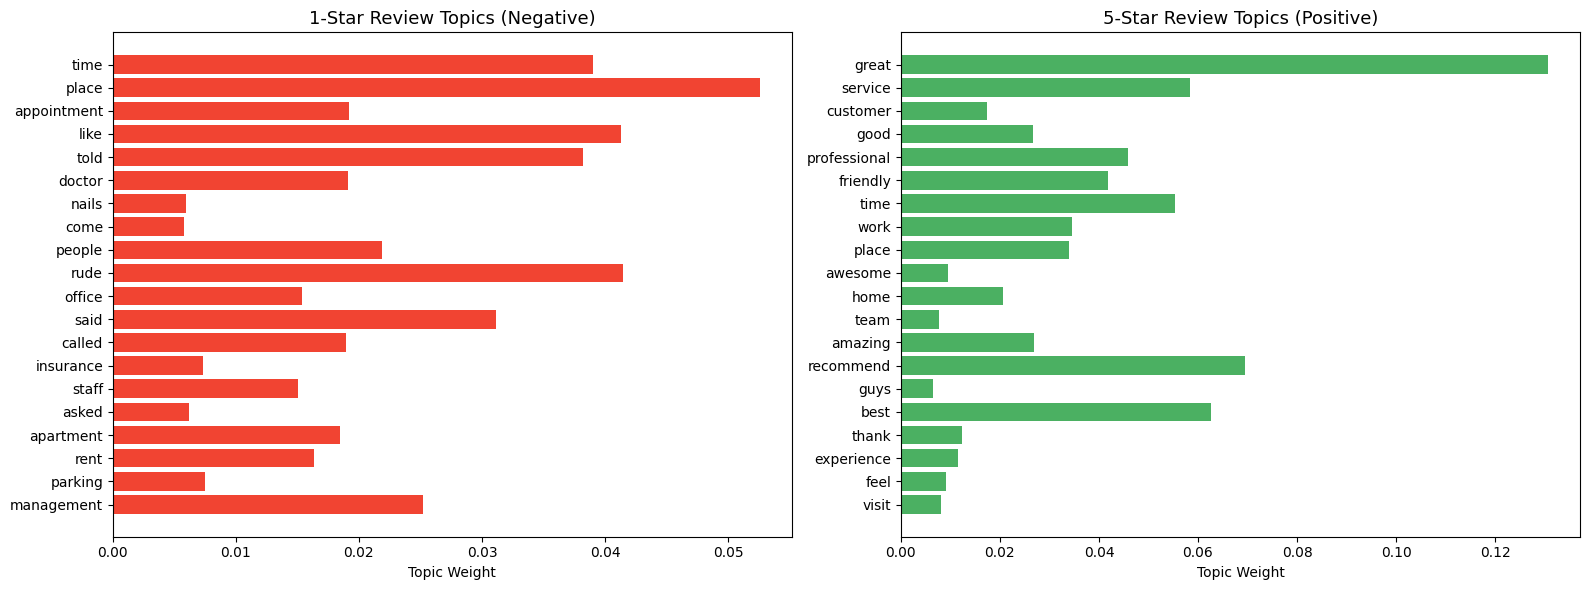

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, lda_model, lda_dict, title, color in zip(
    axes,
    [lda_low, lda_high],
    [low_dict, high_dict],
    ['1-Star Review Topics (Negative)', '5-Star Review Topics (Positive)'],
    ['Reds', 'Greens']
):
    # Get top words from all topics combined
    word_freq = {}
    for topic_id in range(10):
        for word, prob in lda_model.show_topic(topic_id, topn=10):
            word_freq[word] = word_freq.get(word, 0) + prob

    words  = list(word_freq.keys())[:20]
    scores = list(word_freq.values())[:20]

    ax.barh(words, scores, color=plt.cm.get_cmap(color)(0.6))
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Topic Weight')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

In [ ]:
pyLDAvis.enable_notebook()
vis = gensimvis.prepare(lda_low, low_corpus, low_dict)
pyLDAvis.display(vis)

# Group Contribution:

**Safwan (H00531800)**: Performed data preprocessing, text cleaning, and feature engineering (TF-IDF, n-grams).

**P.Harinath Reddy (H00530259)**: Implemented and evaluated machine learning models, including cross-validation and hyperparameter tuning.

**A.Chandrahas(H00530257)**: Developed the sequence model (LSTM/Transformer), conducted topic modelling (LDA), and handled report writing and Kaggle submissions.

All members contributed equally to discussions, analysis.